# 🎮 Video Games Sales — Analisi Esplorativa

Analisi esplorativa e pulizia del dataset sulle vendite di videogiochi.

**Fasi del notebook:**
1. Importazione librerie e caricamento dati
2. Esplorazione iniziale
3. Rimozione duplicati
4. Gestione valori nulli
5. Normalizzazione e pulizia colonne
6. Gestione outlier
7. Analisi e Visualizzazioni


---
## 1. Importazione librerie e caricamento dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carico il dataset da file CSV
df = pd.read_csv('VideoGamesSales.csv')

# Verifico le dimensioni: (righe, colonne)
df.shape

(5909, 15)

---
## 2. Esplorazione iniziale

Prima lettura del dataset: struttura, tipi di dato e prime righe.


In [3]:
# Anteprima delle prime 10 righe per capire la struttura del dataset
df.head(10)

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,NA_Sales,Global_Sales,NA_Profit,Global_Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,$41.49,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,$29.08,40.24,8.724,12.072
2,3,Mario Kart Wii,Wii,2010,Mar,Racing,Nintendo,United States,Louisville,Kentucky,South,$15.85,35.82,4.755,10.746
3,4,Wii Sports Resort,Wii,2010,Apr,Sports,Nintendo,United States,Round Rock,Texas,Central,$15.75,33.00,4.725,9.900
4,5,Pokemon Red/Pokemon Blue,GB,2010,May,Role-Playing,Nintendo,United States,Nashville,Tennessee,South,$11.27,31.37,3.381,9.411
5,6,Tetris,GB,2010,Jun,Puzzle,Nintendo,USA,Newark,Ohio,East,$23.20,30.26,6.960,9.078
6,7,New Super Mario Bros.,DS,2010,Jul,Platform,Nintendo,USA,Fremont,Nebraska,Central,$11.38,30.01,3.414,9.003
7,8,Wii Play,Wii,2010,Aug,Misc,Nintendo,USA,Odessa,Texas,Central,$14.03,29.02,4.209,8.706
8,9,New Super Mario Bros. Wii,Wii,2010,Sep,Platform,Nintendo,USA,Fairfield,Ohio,East,$14.59,28.62,4.377,8.586
9,9,New Super Mario Bros. Wii,Wii,2010,Sep,Platform,Nintendo,USA,Fairfield,Ohio,East,$14.59,28.62,4.377,8.586


In [4]:
# Normalizzo il nome del paese per uniformità (es. 'United States' → 'USA')
df['Country'].replace('United States', 'USA', inplace=True)

C:\Users\Amministratore\AppData\Local\Temp\ipykernel_6840\1987467252.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].replace('United States', 'USA', inplace=True)


In [5]:
# Panoramica generale: tipi di dato, valori non nulli e memoria utilizzata
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5909 entries, 0 to 5908
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           5909 non-null   int64  
 1   Name           5909 non-null   object 
 2   Platform       5909 non-null   object 
 3   Year           5909 non-null   int64  
 4   Month          5909 non-null   object 
 5   Genre          5909 non-null   object 
 6   Publisher      5897 non-null   object 
 7   Country        5909 non-null   object 
 8   City           5909 non-null   object 
 9   State          5909 non-null   object 
 10  Region         5882 non-null   object 
 11  NA_Sales       5909 non-null   object 
 12  Global_Sales   5909 non-null   float64
 13  NA_Profit      5909 non-null   float64
 14  Global_Profit  5909 non-null   float64
dtypes: float64(3), int64(2), object(10)
memory usage: 692.6+ KB


---
## 3. Rimozione duplicati

Individuazione e rimozione delle righe duplicate prima di procedere con la pulizia.


In [6]:
# Identifico le righe duplicate
df_dup = df[df.duplicated()]
print(f'Righe duplicate trovate: {df_dup.shape[0]}')


Righe duplicate trovate: 16


In [7]:
# Rimuovo i duplicati e verifico la nuova dimensione del DataFrame
df = df.drop_duplicates()
print(f'Shape dopo rimozione duplicati: {df.shape}')


Shape dopo rimozione duplicati: (5893, 15)


---
## 4. Gestione valori nulli

Analisi dei valori mancanti e strategia di imputazione:
- **Publisher**: valori nulli sostituiti con `'Unknown'`
- **Region**: sostituzione a cascata usando prima la città, poi il paese come backup


In [8]:
# Conteggio valori nulli per colonna
df.isna().sum()

Rank              0
Name              0
Platform          0
Year              0
Month             0
Genre             0
Publisher        12
Country           0
City              0
State             0
Region           27
NA_Sales          0
Global_Sales      0
NA_Profit         0
Global_Profit     0
dtype: int64

In [9]:
# Publisher: non avendo informazioni aggiuntive, sostituisco i nulli con 'Unknown'
df['Publisher'] = df['Publisher'].fillna('Unknown')

In [10]:
# Region: creo due dizionari di mapping dalle righe già complete
# - city_to_region   : associa ogni città alla sua regione
# - country_to_region: associa ogni paese alla sua regione (backup)

city_to_region    = df.dropna(subset=['Region', 'City']).set_index('City')['Region'].to_dict()
country_to_region = df.dropna(subset=['Region', 'Country']).set_index('Country')['Region'].to_dict()

In [11]:
# Sostituzione a cascata:
# 1° tentativo: risalgo alla regione tramite la città
df['Region'] = df['Region'].fillna(df['City'].map(city_to_region))

# 2° tentativo (backup): se la città non ha risolto tutti i NaN, uso il paese
df['Region'] = df['Region'].fillna(df['Country'].map(country_to_region))

In [12]:
# Verifica finale: nessun valore nullo dovrebbe essere rimasto
df.isna().sum()

Rank             0
Name             0
Platform         0
Year             0
Month            0
Genre            0
Publisher        0
Country          0
City             0
State            0
Region           0
NA_Sales         0
Global_Sales     0
NA_Profit        0
Global_Profit    0
dtype: int64

---
## 5. Normalizzazione e pulizia colonne

- Conversione di `NA_Sales` da stringa (con simbolo `$`) a tipo numerico
- Rinomina delle colonne per coerenza e leggibilità


In [13]:
# Rimuovo il simbolo '$' dalla colonna NA_Sales
# Uso [$] invece di \$ per cercare il carattere ovunque nella stringa
df['NA_Sales'] = df['NA_Sales'].replace('[$]', '', regex=True)

# Converto la colonna in tipo numerico (era originariamente object/string)
df['NA_Sales'] = pd.to_numeric(df['NA_Sales'])

print('Tipo di NA_Sales dopo conversione:', df['NA_Sales'].dtype)

Tipo di NA_Sales dopo conversione: float64


In [14]:
# Rinomino le colonne per uniformità e maggiore chiarezza
df = df.rename(columns={
    'NA_Sales'     : 'National Sales',
    'Global_Sales' : 'Global Sales',
    'NA_Profit'    : 'National Profit',
    'Global_Profit': 'Global Profit'
})

# Verifica della struttura finale del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5893 entries, 0 to 5908
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             5893 non-null   int64  
 1   Name             5893 non-null   object 
 2   Platform         5893 non-null   object 
 3   Year             5893 non-null   int64  
 4   Month            5893 non-null   object 
 5   Genre            5893 non-null   object 
 6   Publisher        5893 non-null   object 
 7   Country          5893 non-null   object 
 8   City             5893 non-null   object 
 9   State            5893 non-null   object 
 10  Region           5893 non-null   object 
 11  National Sales   5893 non-null   float64
 12  Global Sales     5893 non-null   float64
 13  National Profit  5893 non-null   float64
 14  Global Profit    5893 non-null   float64
dtypes: float64(4), int64(2), object(9)
memory usage: 736.6+ KB


---
## 6. Gestione outlier

I valori oltre il **95° percentile** vengono sostituiti con il valore soglia,
evitando di eliminare righe e preservando la distribuzione complessiva.
La soglia viene calcolata **separatamente** per vendite nazionali e globali.


In [15]:
# Calcolo le soglie al 95° percentile per ciascuna colonna
national_cap = df['National Sales'].quantile(0.95)
global_cap   = df['Global Sales'].quantile(0.95)

print(f'Soglia National Sales (95° pct): {national_cap}')
print(f'Soglia Global Sales  (95° pct): {global_cap}')

# Applico il capping: i valori oltre la soglia vengono sostituiti con la soglia stessa
df['National Sales'] = np.where(df['National Sales'] > national_cap, national_cap, df['National Sales'])
df['Global Sales']   = np.where(df['Global Sales']   > global_cap,   global_cap,   df['Global Sales'])


Soglia National Sales (95° pct): 2.07
Soglia Global Sales  (95° pct): 4.037999999999993


---
## 7. Analisi e Visualizzazioni

Esploro le vendite attraverso quattro visualizzazioni:
- **Bar chart**: vendite nazionali per regione e paese
- **Box plot**: distribuzione vendite nei top 3 generi per paese
- **Pie chart**: quota di mercato nazionale e globale per paese
- **Line chart**: andamento delle vendite nel tempo


### 7a. Vendite nazionali per Regione e Paese

In [16]:
# Aggregazione: somma delle vendite nazionali raggruppata per Region e Country
National_Sales_by_region = (
    df.groupby(['Region', 'Country'])['National Sales']
    .sum()
    .reset_index()
    .sort_values(by='National Sales', ascending=False)
)

National_Sales_by_region

,Region,Country,National Sales
8,West,USA,801.49
7,West,Australia,687.18
2,East,USA,673.34
0,Central,USA,564.46
6,South,USA,408.63
4,Other,Australia,28.21
5,South,Australia,16.30
3,North,Australia,11.68
1,East,Australia,1.35


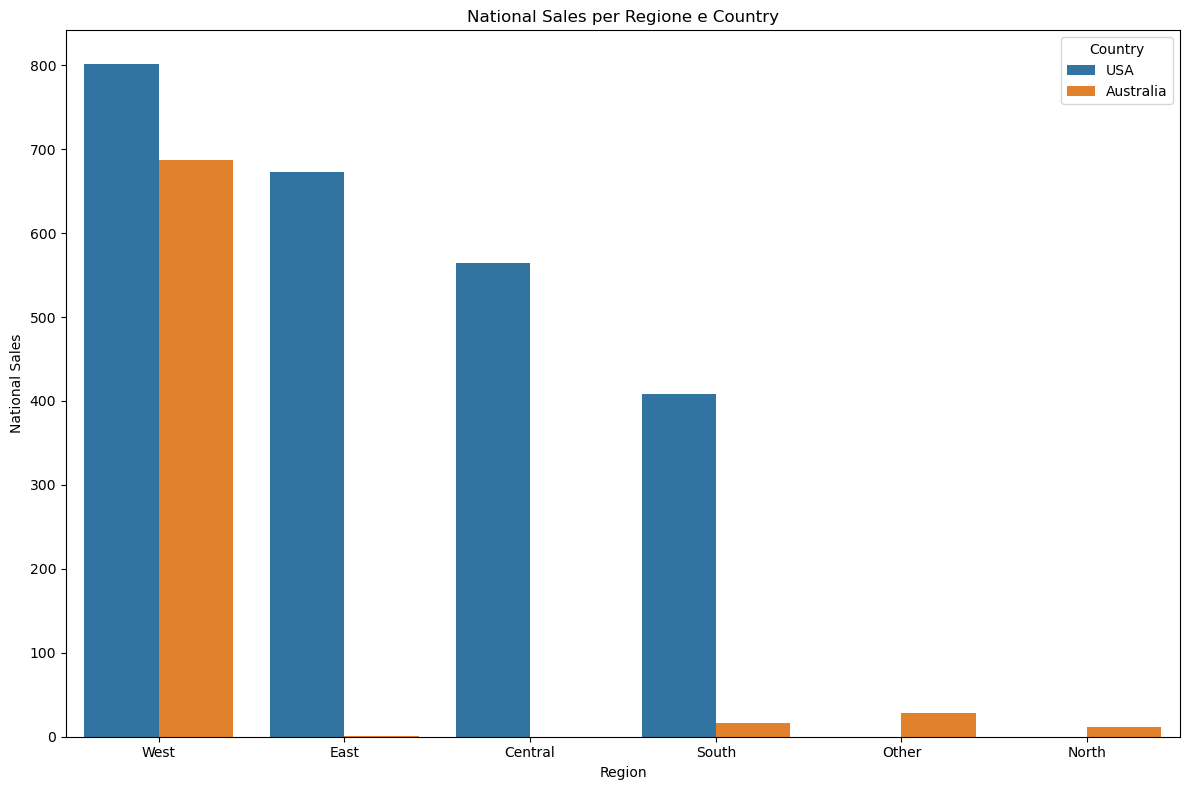

In [17]:
plt.figure(figsize=(12, 8))

sns.barplot(data=National_Sales_by_region, x='Region', y='National Sales', hue='Country')

plt.title('National Sales per Regione e Country')
plt.xlabel('Region')
plt.ylabel('National Sales')
plt.tight_layout()
plt.show()


### 7b. Distribuzione vendite nei Top 3 Generi per Paese

In [18]:
# Identifico i 3 generi con le vendite nazionali totali più alte
Top_3_Genre = (
    df.groupby('Genre')['National Sales']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index.to_list()
)

# Filtro il DataFrame mantenendo solo le righe dei top 3 generi
df_top_3 = df[df['Genre'].isin(Top_3_Genre)]

print('Top 3 generi:', Top_3_Genre)


Top 3 generi: ['Action', 'Sports', 'Shooter']


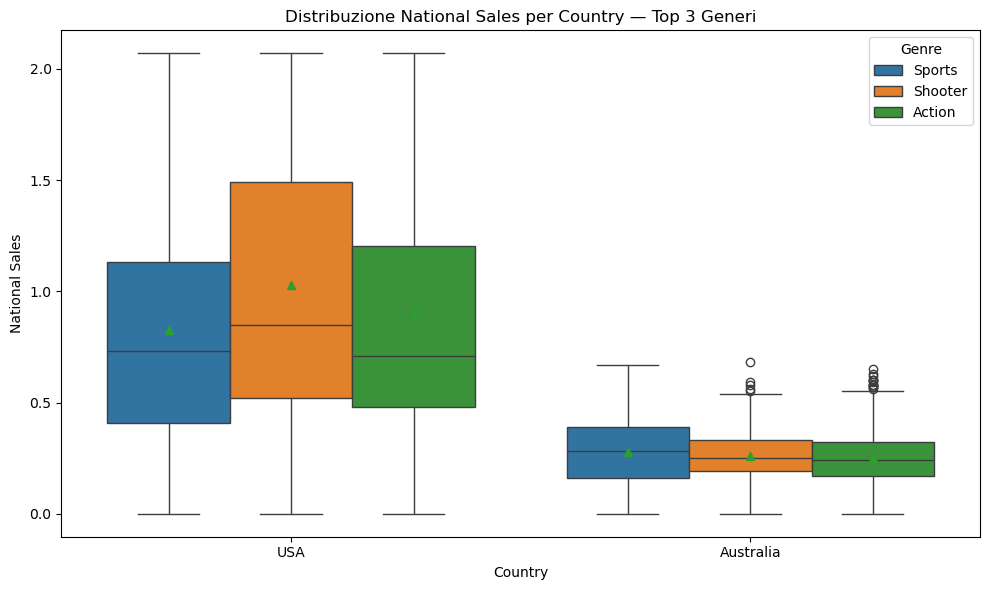

In [19]:
plt.figure(figsize=(10, 6))

# hue='Genre' colora le box in base al genere; showmeans mostra la media
sns.boxplot(data=df_top_3, x='Country', y='National Sales', hue='Genre', showmeans=True)

plt.title('Distribuzione National Sales per Country — Top 3 Generi')
plt.xlabel('Country')
plt.ylabel('National Sales')
plt.tight_layout()
plt.show()


### 7c. Quota di mercato per Paese (Pie chart)

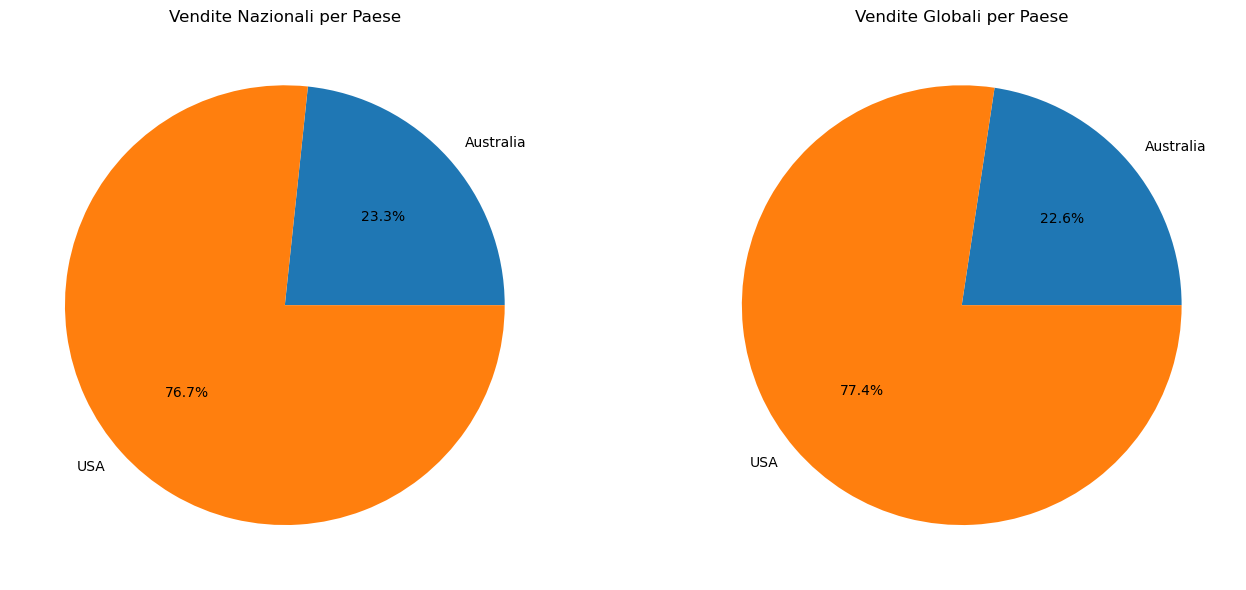

In [20]:
# Aggregazione: somma vendite nazionali e globali per paese
Sales_by_country = df.groupby('Country')[['National Sales', 'Global Sales']].sum().reset_index()

country_labels  = Sales_by_country['Country']
national_values = Sales_by_country['National Sales']
global_values   = Sales_by_country['Global Sales']

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].pie(national_values, labels=country_labels, autopct='%1.1f%%')
ax[0].set_title('Vendite Nazionali per Paese')

ax[1].pie(global_values, labels=country_labels, autopct='%1.1f%%')
ax[1].set_title('Vendite Globali per Paese')

plt.tight_layout()
plt.show()


### 7d. Andamento vendite nel tempo (Line chart)

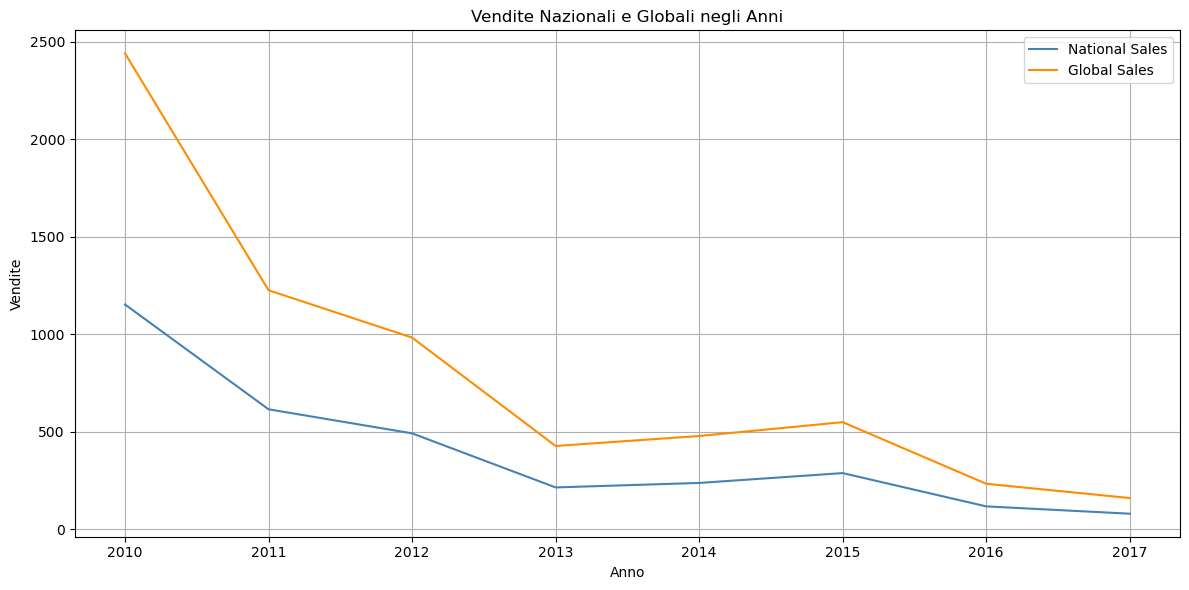

In [21]:
# Aggregazione: somma vendite per anno
Sales_by_year = (
    df.groupby('Year')[['National Sales', 'Global Sales']]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(Sales_by_year['Year'], Sales_by_year['National Sales'], color='steelblue', label='National Sales')
plt.plot(Sales_by_year['Year'], Sales_by_year['Global Sales'],   color='darkorange', label='Global Sales')

plt.title('Vendite Nazionali e Globali negli Anni')
plt.xlabel('Anno')
plt.ylabel('Vendite')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
